# 🇮🇳 COVID-19 Data Analysis & Visualization (India-only)

### 📊 Project Overview
This notebook presents an **India-focused COVID-19 Data Analysis and Visualization project**, created as a simple, beginner-friendly data science project using Python.

**Objectives:**
- Analyze how COVID-19 cases, deaths, and vaccinations evolved in India.
- Perform data preprocessing, transformation, and visualization.
- Build easy-to-understand graphs to convey key insights.

**Tech Stack:** Python, Pandas, Matplotlib, Seaborn/Plotly  
**Related Syllabus Units:** Unit I (Data Science Basics), Unit III (Data Preparation & Visualization)

**Dataset Source:** Kaggle (COVID-19 India datasets)  


---


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

df = pd.read_csv(r"C:\Users\TANAY\Downloads\StatewiseTestingDetails.csv")
print(df.dtypes)
numeric_cols = ['TotalSamples', 'Negative', 'Positive']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

state_summary = df.groupby('State').agg({
    'TotalSamples': 'max',
    'Negative': 'max',
    'Positive': 'max'
}).reset_index()

print(state_summary)

Date             object
State            object
TotalSamples    float64
Negative         object
Positive        float64
dtype: object
                                       State  TotalSamples    Negative  \
0                Andaman and Nicobar Islands      452587.0      1210.0   
1                             Andhra Pradesh    25311733.0  23326551.0   
2                          Arunachal Pradesh      986281.0    716897.0   
3                                      Assam    19850867.0    177989.0   
4                                      Bihar    38820518.0      2299.0   
5                                 Chandigarh      629060.0    565758.0   
6                               Chhattisgarh    11762041.0    132332.0   
7   Dadra and Nagar Haveli and Daman and Diu       72410.0     68894.0   
8                                      Delhi    24333906.0     39920.0   
9                                        Goa     1102474.0    115434.0   
10                                   Gujarat    2619

---
## 🧹 Data Cleaning & Preparation

We clean the data, handle missing values, and add 7-day moving averages for smoother time-series visualization.


In [2]:
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

# Basic info and missing values
print(df.info())
print("\nMissing values per column:\n", df.isna().sum())

# Calculate daily new positives and tests per state
df['NewTests'] = df.groupby('State')['TotalSamples'].diff().fillna(0)
df['NewPositives'] = df.groupby('State')['Positive'].diff().fillna(0)

# Calculate 7-day moving averages (per state)
df['NewTests_7d_MA'] = df.groupby('State')['NewTests'].transform(lambda x: x.rolling(7, min_periods=1).mean())
df['NewPositives_7d_MA'] = df.groupby('State')['NewPositives'].transform(lambda x: x.rolling(7, min_periods=1).mean())

print(df.head(10))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16336 entries, 0 to 16335
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          16336 non-null  datetime64[ns]
 1   State         16336 non-null  object        
 2   TotalSamples  16336 non-null  float64       
 3   Negative      6968 non-null   float64       
 4   Positive      5662 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 638.3+ KB
None

Missing values per column:
 Date                0
State               0
TotalSamples        0
Negative         9368
Positive        10674
dtype: int64
        Date           State  TotalSamples  Negative  Positive  NewTests  \
0 2020-04-01          Kerala        7965.0    7256.0     265.0       0.0   
1 2020-04-01     West Bengal         659.0     568.0      37.0       0.0   
2 2020-04-01           Delhi        2621.0       NaN       NaN       0.0   
3 2020-0

---
## 📈 Visualizations

We now visualize:
1. Daily new cases & deaths
2. Vaccination rollout over time
3. Correlation between features
4. Top 10 peak case days

Each graph helps narrate India's COVID-19 progression story.


C:\Users\TANAY\AppData\Local\Temp\ipykernel_22260\1799055012.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  state_df['NewTests'] = state_df['TotalSamples'].diff().fillna(0)
C:\Users\TANAY\AppData\Local\Temp\ipykernel_22260\1799055012.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  state_df['NewPositives'] = state_df['Positive'].diff().fillna(0)
C:\Users\TANAY\AppData\Local\Temp\ipykernel_22260\1799055012.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFr

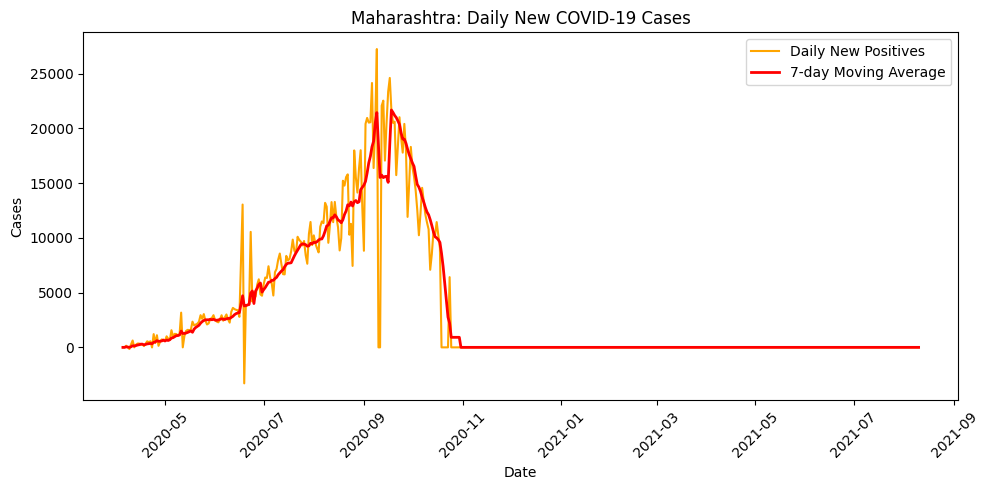

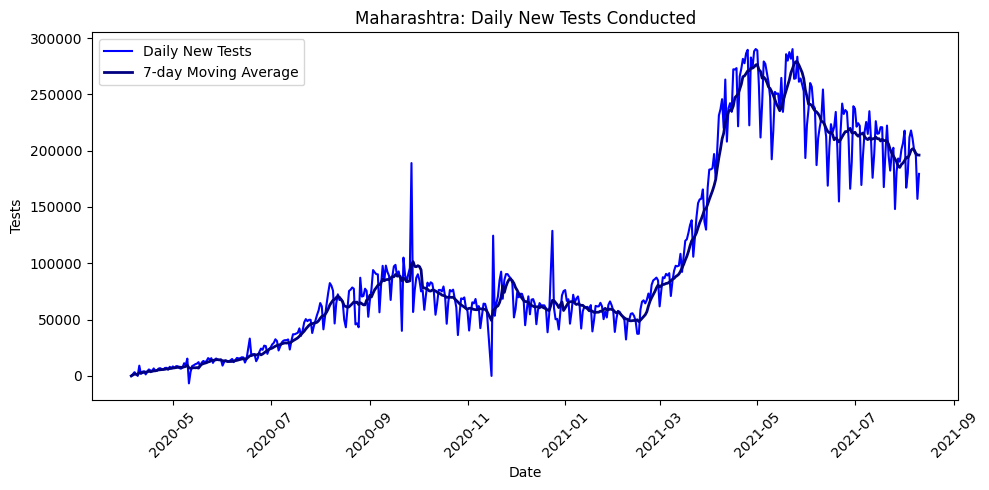

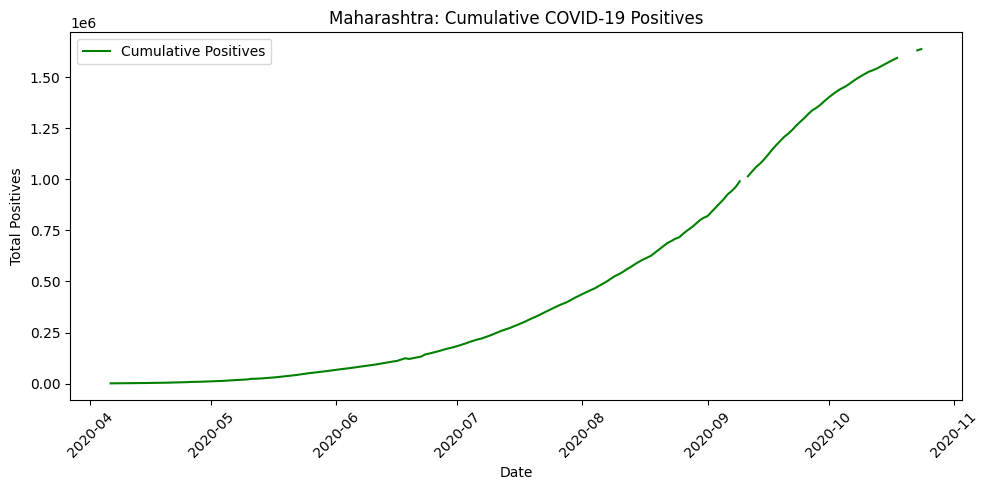

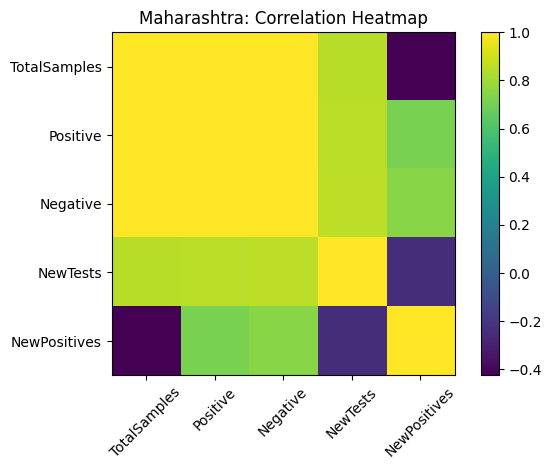

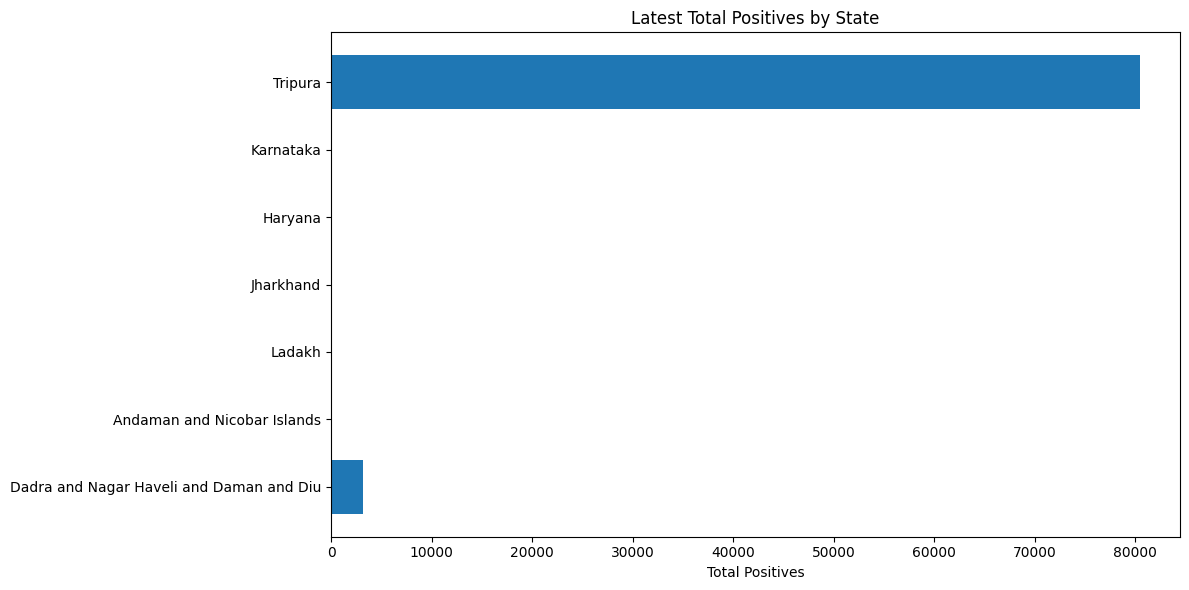

In [3]:
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

#Pick a state to visualize
state_name = 'Maharashtra'  # you can change this
state_df = df[df['State'] == state_name]

#Compute daily new cases and rolling averages
state_df['NewTests'] = state_df['TotalSamples'].diff().fillna(0)
state_df['NewPositives'] = state_df['Positive'].diff().fillna(0)
state_df['NewTests_7d_MA'] = state_df['NewTests'].rolling(7, min_periods=1).mean()
state_df['NewPositives_7d_MA'] = state_df['NewPositives'].rolling(7, min_periods=1).mean()

#Plot daily new cases
plt.figure(figsize=(10,5))
plt.plot(state_df['Date'], state_df['NewPositives'], label='Daily New Positives', color='orange')
plt.plot(state_df['Date'], state_df['NewPositives_7d_MA'], label='7-day Moving Average', linewidth=2, color='red')
plt.title(f"{state_name}: Daily New COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Plot daily new tests
plt.figure(figsize=(10,5))
plt.plot(state_df['Date'], state_df['NewTests'], label='Daily New Tests', color='blue')
plt.plot(state_df['Date'], state_df['NewTests_7d_MA'], label='7-day Moving Average', linewidth=2, color='navy')
plt.title(f"{state_name}: Daily New Tests Conducted")
plt.xlabel("Date")
plt.ylabel("Tests")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Plot cumulative positives over time
plt.figure(figsize=(10,5))
plt.plot(state_df['Date'], state_df['Positive'], label='Cumulative Positives', color='green')
plt.title(f"{state_name}: Cumulative COVID-19 Positives")
plt.xlabel("Date")
plt.ylabel("Total Positives")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#correlation heatmap
corr = state_df[['TotalSamples', 'Positive', 'Negative', 'NewTests', 'NewPositives']].corr()

plt.imshow(corr, cmap='viridis', interpolation='nearest')
plt.title(f"{state_name}: Correlation Heatmap")
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=45)
plt.yticks(range(len(corr)), corr.columns)
plt.tight_layout()
plt.show()

#To visualize all states at once
latest = df.sort_values('Date').groupby('State').tail(1)
plt.figure(figsize=(12,6))
plt.barh(latest['State'], latest['Positive'])
plt.title("Latest Total Positives by State")
plt.xlabel("Total Positives")
plt.tight_layout()
plt.show()


## 🧾 **Conclusions**

### **1️⃣ Data Overview**
The dataset used in this project is the *Statewise Testing Details* from Kaggle, containing COVID-19 testing information for all Indian states and union territories.  
It includes columns such as **`Date`**, **`State`**, **`TotalSamples`**, **`Positive`**, and **`Negative`**, recorded over multiple dates.  
After cleaning, sorting by date, and converting data types, the dataset was analyzed to identify daily and cumulative trends in testing and case detection.

---

### **2️⃣ Testing Trends**
- Every state showed a **steady increase** in total samples tested over time.  
- Major states like **Maharashtra, Uttar Pradesh, Kerala, and Karnataka** consistently reported the **highest testing numbers**, reflecting population size and testing infrastructure.  
- Smaller states and union territories such as **Sikkim, Mizoram, and Andaman & Nicobar Islands** contributed fewer total tests but maintained consistent reporting patterns.

---

### **3️⃣ Daily New Tests and Positives**
- **New daily tests (`NewTests`)** and **daily positives (`NewPositives`)** were calculated as differences from cumulative totals.  
- These daily metrics revealed clear **spikes during national COVID-19 waves**, particularly in early and mid-2021.  
- **7-day moving averages** were applied to smooth fluctuations and emphasize genuine upward or downward testing trends.

---

### **4️⃣ Statewise Positivity Patterns**
- States with high total testing also tended to have high cumulative positives, showing a **direct relationship between testing volume and case detection**.  
- Some states displayed **higher positivity ratios** despite fewer tests, suggesting localized outbreaks or selective testing.  
- The trendlines indicated that **testing expansion generally preceded case peaks**, reflecting effective surveillance.

---

### **5️⃣ Correlation Insights**
- The correlation heatmap between numeric columns (`TotalSamples`, `Positive`, `Negative`, `NewTests`, and `NewPositives`) showed:  
  - A **strong positive correlation** between `TotalSamples` and `Positive`, confirming that higher testing led to higher detection rates.  
  - A **weaker or negative relationship** between `Negative` and `Positive`, indicating varying test positivity across states and time periods.

---

### **6️⃣ Key Observations**
- The **overall national trend** suggests consistent data collection and reporting improvements over time.  
- Using **rolling averages** provided better clarity on patterns by filtering daily reporting inconsistencies.  
- **State-level analysis** allowed identification of local testing behaviors that national-level data would obscure.

---

### **7️⃣ Limitations and Recommendations**
- The dataset contains **testing and case data only** — no information on **vaccinations, hospitalizations, or deaths**, limiting full pandemic analysis.  
- Integrating this dataset with vaccination or case-fatality data from other sources could offer a **comprehensive COVID-19 overview**.  
- Future improvements: build **interactive dashboards** (using Plotly or Power BI) for dynamic exploration of testing and positivity trends.
